###  import necessary library for this project

In [76]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV


In [77]:
df = pd.read_excel("DS_task.xlsx", sheet_name='STR_sample_data')
df.head(5)

,customer_site_id,orders_1yr,line_items_1yr,days_since_last_purchase_1yr,prop_reduced_items_1yr,promo_customer_blc_1yr,promo_customer_freedelivery_1yr,Brand_Nike_prop_revenue_1yr,Brand_Adidas_prop_revenue_1yr,Device_mobile_prop_revenue_1yr,Device_iosapp_prop_revenue_1yr,Delivery_NextDay_prop_revenue_1yr,Payment_bnpl_prop_revenue_1yr,amount_paid_per_order_1yr,Current_RFM_Segment,ONS_Segment,repurchased
0,JD-40fb5572b02ce75726cc90aadcb676aa4b7c7143cd4...,2.0,3,198.0,0.333333,0,1,0.315789,0.315789,0.000000,0.0,0.0,0.0,100.890,Existing_2. POTENTIALS,ONS_6,0
1,JD-ee4b7217e38b2fbca53c28494b0d59e7ae12f51fc9c...,1.0,1,141.0,1.000000,0,0,1.000000,0.000000,0.000000,0.0,0.0,0.0,238.950,New_3. CASUALS / AVERAGE,ONS_5,0
2,JD-496c75b8905feacee992ee784f7f157b86ae155ff63...,1.0,1,210.0,0.000000,0,0,0.000000,1.000000,0.000000,1.0,0.0,1.0,106.200,Existing_3. CASUALS / AVERAGE,ONS_5,0
3,JD-9000edec54bf90d58ff7f7319d20d3c0855a19f5188...,2.0,7,226.0,0.000000,0,1,0.346756,0.000000,0.346756,0.0,0.0,1.0,395.595,Existing_2. POTENTIALS,ONS_8,0
4,JD-370802c16c3997b62605e29e75f86e19e6dcd6947ac...,2.0,2,69.0,0.000000,0,1,1.000000,0.000000,1.000000,0.0,0.0,0.0,123.900,New_2. POTENTIALS,ONS_4,0


### Variable Definition
customer_site_id (str)  =	Customer Identifier 

orders_1yr (int)  =	Number of orders placed in last 12 months

line_items_1yr (int) = No. of items purchased in last 12 months

days_since_last_purchase_1yr (int) = Days since last purchase inlast 12 months

prop_reduced_items_1yr (float) = Proportion of reduced priced items bought in the last 12 months

promo_customer_blc_1yr (int) = whether the customer used blue light promotion offer in the last 12 months (0, 1)

promo_customer_freedelivery_1yr (int) = whether free delivery was offered to the customer in the last 12 months (0, 1)

Brand_Nike_prop_revenue_1yr (float) = Proportion of revenue from Nike product purchases in the last 12 months

Brand_Adidas_prop_revenue_1yr (float) = Proportion of revenue from Adidas product purchases in the last 12 months

Device_mobile_prop_revenue_1yr (float) = Proportion of revenue from purchases on a mobile device in the last 12 months

Device_iosapp_prop_revenue_1yr (float) = Proportion of revenue from purchases on a ios device in the last 12 months

Delivery_NextDay_prop_revenue_1yr (float) = Proportion of revenue from purchases with Next Day Delivery in the last 12 months

Payment_bnpl_prop_revenue_1yr (float) = whether the customer used bnpl ( buy now pay later) in the last 12 months

amount_paid_per_order_1yr (float) = Total order amount before delivery

Current_RFM_Segment (str) 	= RFM (Recency, Frequency, Monetary) segment of the customer

ONS_Segment (str)  = Socio-demographic segment fo the customer ( from ONS)

repurchased (int)	= Whether the customer made a repeat purchase in the next 3 months (0, 1)

In [78]:
# Iterate over each column in the dataframe to understand the unique values in each column
for column in df.columns:
    print(f"Unique values in '{column}':")
    print(df[column].unique())
    print("-------------------------") 

Unique values in 'customer_site_id':
['JD-40fb5572b02ce75726cc90aadcb676aa4b7c7143cd4a8db6da316485ad005575'
 'JD-ee4b7217e38b2fbca53c28494b0d59e7ae12f51fc9c5dfac6ccd43ee55799713'
 'JD-496c75b8905feacee992ee784f7f157b86ae155ff6314a81731ebfee93e7ae47' ...
 'JD-29343c051c2445dac7f6d51fdb798cc9e9699006e42ffc054d92a532288d29ce'
 'JD-9fad1299c4b5e52671576004a0ca3dfcb59b3bd566b1afc9d6d3d1addff0894b'
 'JD-40b41c0e2127d1207009e2e7d2b6f68a14d48640c7a90c65f972728f8b8c1ce4']
-------------------------
Unique values in 'orders_1yr':
[  2.   1.   4.   8.   5.   3.  nan   7.  10.   6.   9.  13.  20.  12.
  11.   0.  21.  19.  22.  15.  17.  14.  18.  16.  29.  46.  36. 286.
  33.  37.  30.  41.  23.  38.  24.  28.  35.  31.  26.  40.  25.  55.
  51.  49.  27.  63.  50. 101.  32.  64.  42.  43.  70.  65.  45.  58.
  39.  44.  73.  54.  34.  56.  94.  67.  53. 195. 142.  66.  57.  82.
 106.]
-------------------------
Unique values in 'line_items_1yr':
[  3   1   7   2   6  10  12   4   8  31  16   5  14

#### Clean the dataset, remove the nan value and empty column in the dataset
Remove missing data in the record and map some string columns to make it comparable with other feature for model training and the peason correlation analysis

In [79]:
print(df.isnull().sum())
df = df.dropna()

customer_site_id                     0
orders_1yr                           8
line_items_1yr                       0
days_since_last_purchase_1yr         8
prop_reduced_items_1yr               0
promo_customer_blc_1yr               0
promo_customer_freedelivery_1yr      0
Brand_Nike_prop_revenue_1yr          0
Brand_Adidas_prop_revenue_1yr        0
Device_mobile_prop_revenue_1yr       0
Device_iosapp_prop_revenue_1yr       0
Delivery_NextDay_prop_revenue_1yr    0
Payment_bnpl_prop_revenue_1yr        0
amount_paid_per_order_1yr            0
Current_RFM_Segment                  0
ONS_Segment                          0
repurchased                          0
dtype: int64


Convert type text to categorical variables (Current_RFM_Segment, ONS_Segment) : Because in the Current_RFM_Segment column there is a natural order in the categories (i.e., one category is "VIP", "POTENTIALS" and "CASUALS"), so we assign numeric values directly to each category.

In [80]:
rfm_mapping = {
    'Existing_1. VIP': 9,
    'New_1. VIP': 8,
    'Existing_2. POTENTIALS': 7,
    'New_2. POTENTIALS': 6,
    'Existing_3. CASUALS / AVERAGE': 5,
    'New_3. CASUALS / AVERAGE': 4,
    'Existing_4. LAPSED': 3,
    'Existing_5. DORMANT': 2,
    'UNKNOWN': 1
}

ons_mapping = {
    'ONS_1': 1,
    'ONS_2': 2,
    'ONS_3': 3,
    'ONS_4': 4,
    'ONS_5': 5,
    'ONS_6': 6,
    'ONS_7': 7,
    'ONS_8': 8,
    'ONS_Unknown': 9
}

df['Current_RFM_Segment'] = df['Current_RFM_Segment'].map(rfm_mapping)
df['ONS_Segment'] = df['ONS_Segment'].map(ons_mapping)

A Pearson correlation matrix shows the linear relationships between features in dataframe, with values ranging from -1 to 1. A correlation of 1 means a perfect positive relationship, -1 indicates a perfect negative relationship, and 0 means no linear relationship.

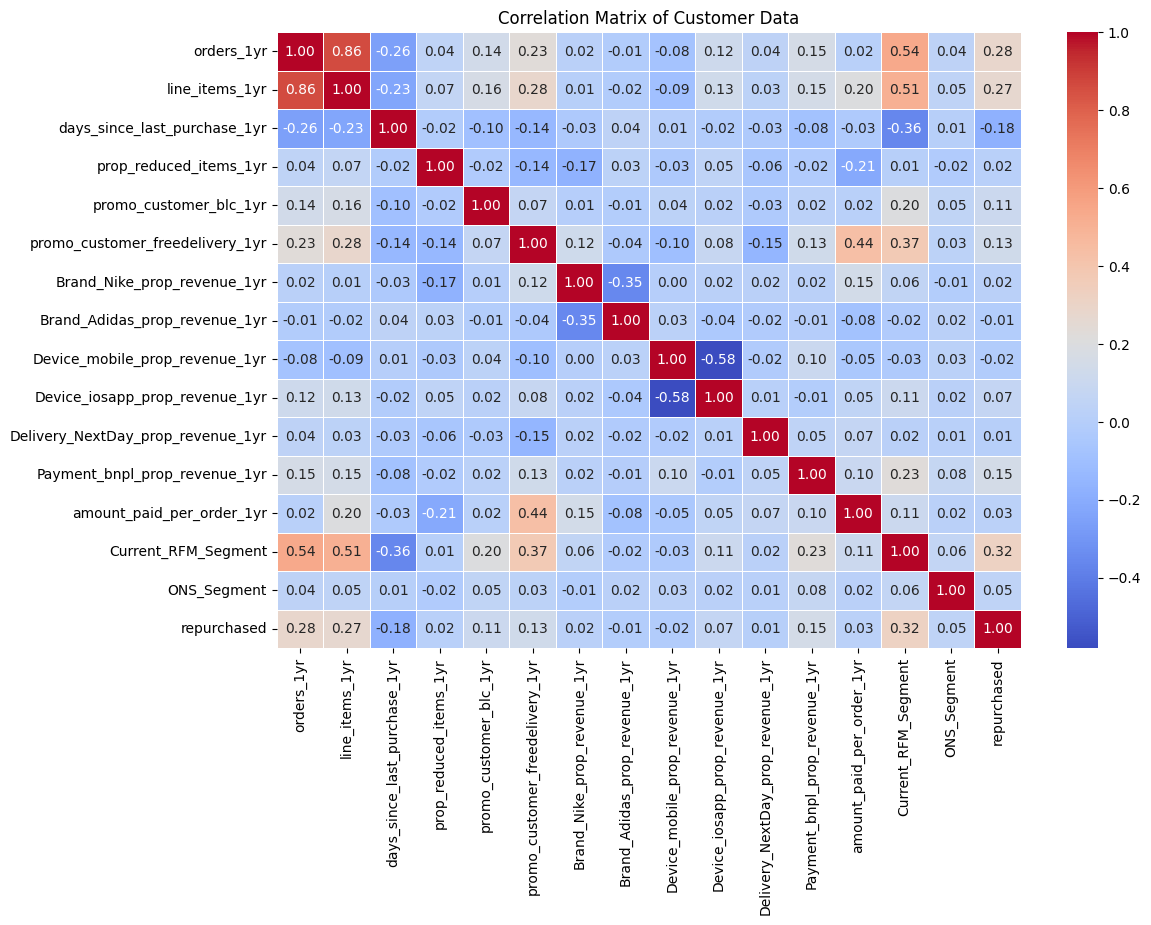

In [81]:
df_corr = df.drop(columns=['customer_site_id'])
plt.figure(figsize=(12, 8))  
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Customer Data')
plt.show()

#### Visualization 
show the relationship between target feature (repurchased) and other important feature based on pearson correlation analysis

In [82]:
df['rfm_mapped'] = df['Current_RFM_Segment'].map({v: k for k, v in rfm_mapping.items()})

fig = px.histogram(
    df,  
    x='rfm_mapped',  
    color='repurchased',  
    barmode='group',  
    histfunc='count',  
    labels={'rfm_mapped': 'RFM Segment', 'repurchased': 'Repurchase Status'},  
    title='Histogram of RFM Segments Categorized by Repurchase Status'
)

fig.update_layout(
    xaxis_title='RFM Segment',
    yaxis_title='Count of Customers',
    xaxis={'categoryorder':'array', 'categoryarray': list(rfm_mapping.keys())},  
    legend_title='Repurchased (0=No, 1=Yes)',
    xaxis_tickangle=45  
)

fig.show()

In [13]:
rfm_group = df.groupby('Current_RFM_Segment').agg({
    'orders_1yr': 'mean',
    'line_items_1yr': 'mean',
}).reset_index()

trace_mean_order = go.Scatter(
    x=rfm_group['Current_RFM_Segment'],  
    y=rfm_group['orders_1yr'],
    mode='lines+markers',
    name='Mean Orders per Year'
)

trace_mean_line = go.Scatter(
    x=rfm_group['Current_RFM_Segment'], 
    y=rfm_group['line_items_1yr'],
    mode='lines+markers',
    name='Mean Line Items per Year'
)

layout = go.Layout(
    title='RFM Segment Analysis',
    xaxis=dict(
        title='RFM Segment (Ordinal)',
        tickvals=list(rfm_mapping.values()),  
        ticktext=list(rfm_mapping.keys()),    
        tickangle=45,                          
    ),
    yaxis=dict(
        title='Value'
    ),
    legend=dict(
        x=1.05,  
        y=1,     
        traceorder='normal',  
        orientation='v',      
    ),
)

fig = go.Figure(data=[trace_mean_order, trace_mean_line], layout=layout)
fig.show()


In [12]:
reverse_rfm_mapping = {v: k for k, v in rfm_mapping.items()}

df_filtered = df[df['repurchased'] == 1]
df_filtered['Current_RFM_Segment_Text'] = df_filtered['Current_RFM_Segment'].map(reverse_rfm_mapping)

segment_counts = df_filtered['Current_RFM_Segment_Text'].value_counts()
total = segment_counts.sum()
segment_percentages = (segment_counts / total) * 100

# Combine segments that have less than 1% into 'Other'
other_category = segment_counts[segment_percentages < 1].sum()
segment_counts_filtered = segment_counts[segment_percentages >= 1]
segment_counts_filtered['Other'] = other_category

fig = go.Figure(data=[go.Pie(
    labels=segment_counts_filtered.index,
    values=segment_counts_filtered.values,
    hole=0.7, 
    textinfo='label+percent',
    marker=dict(colors=sns.color_palette("husl", len(segment_counts_filtered))),
    textfont=dict(size=14, color='black'),  
    showlegend=False, 
)])

fig.update_layout(
    title='Distribution of Current RFM Segment for Repurchased Customers',
    showlegend=True
)

fig.show()


### Model training : Classification problem predict target (repurchased) or not

split the dataset (80:20) to train for training the model and testing for validate the model prediction

In [18]:
X = df.drop(columns=['customer_site_id', 'repurchased', 'rfm_mapped'])
y = df['repurchased']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Decision Tree (Baseline model)

In [27]:
%%time
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.85      0.86     17123
           1       0.28      0.32      0.30      3076

    accuracy                           0.77     20199
   macro avg       0.58      0.59      0.58     20199
weighted avg       0.79      0.77      0.78     20199

CPU times: user 347 ms, sys: 24.6 ms, total: 372 ms
Wall time: 372 ms


### Random Forest (Baseline model)

In [32]:
%%time
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.98      0.92     17123
           1       0.59      0.19      0.29      3076

    accuracy                           0.86     20199
   macro avg       0.73      0.58      0.60     20199
weighted avg       0.83      0.86      0.82     20199

CPU times: user 5.57 s, sys: 140 ms, total: 5.71 s
Wall time: 5.79 s


### Xgboosts (Baseline model)

In [34]:
xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.98      0.92     17123
           1       0.59      0.18      0.28      3076

    accuracy                           0.86     20199
   macro avg       0.73      0.58      0.60     20199
weighted avg       0.83      0.86      0.82     20199

CPU times: user 581 ms, sys: 386 ms, total: 968 ms
Wall time: 316 ms


<Figure size 1000x600 with 0 Axes>

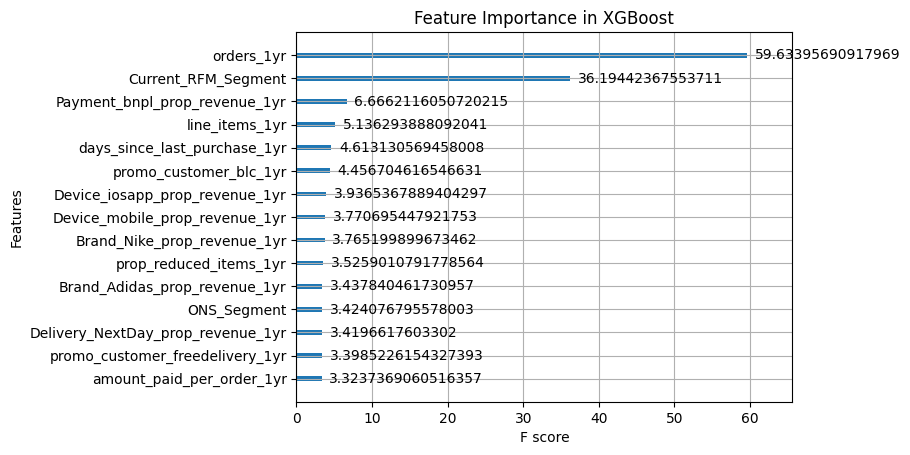

In [35]:
plt.figure(figsize=(10, 6))
plot_importance(xgb_model, importance_type='gain')
plt.title('Feature Importance in XGBoost')
plt.show()

Remove unimportance feature from the dataset: Increase the speed of model and reduce complexity of trhe model 

In [40]:
columns_to_remove = ['promo_customer_freedelivery_1yr', 
                      'Delivery_NextDay_prop_revenue_1yr', 'ONS_Segment', 
                      'Brand_Adidas_prop_revenue_1yr', 'prop_reduced_items_1yr', 'Brand_Nike_prop_revenue_1yr',
                      'Device_mobile_prop_revenue_1yr', 'Device_iosapp_prop_revenue_1yr', 'promo_customer_blc_1yr',
                      'Payment_bnpl_prop_revenue_1yr', 'amount_paid_per_order_1yr']

X_train = X_train.drop(columns=columns_to_remove, errors='ignore')
X_test = X_test.drop(columns=columns_to_remove, errors='ignore')

In [44]:
X_train.columns

Index(['orders_1yr', 'line_items_1yr', 'days_since_last_purchase_1yr',
       'Current_RFM_Segment'],
      dtype='object')

In [ ]:
def get_confusion_matrix(y_test, y_pred, title_name):
    conf_matrix = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title_name)
    plt.show()

### Train XGBoost model : With removed features data

In [62]:
%%time
xgb_rm_model = XGBClassifier(random_state=42)
xgb_rm_model.fit(X_train, y_train)
y_pred = xgb_rm_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.98      0.92     17123
           1       0.60      0.16      0.25      3076

    accuracy                           0.86     20199
   macro avg       0.73      0.57      0.59     20199
weighted avg       0.83      0.86      0.82     20199

CPU times: user 348 ms, sys: 425 ms, total: 773 ms
Wall time: 292 ms


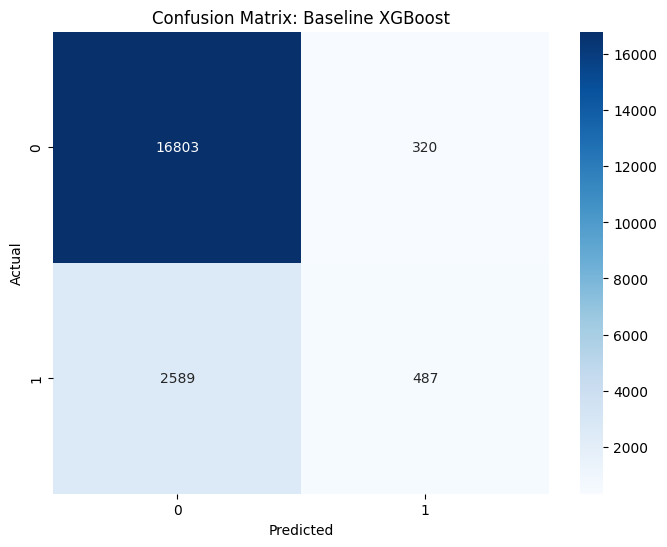

In [66]:
get_confusion_matrix(y_test, y_pred, 'Confusion Matrix: Baseline XGBoost')

To handle imbalanced datasets in XGBoost, you can use several strategies to avoid the model from over-predicting the majority class. One common approach is to use the scale_pos_weight parameter, which helps balance the weight of the minority class relative to the majority class. Here's how you can adjust the model to handle imbalance:

scale_pos_weight [default=1]
Control the balance of positive and negative weights, useful for unbalanced classes. A typical value to consider: sum(negative instances) / sum(positive instances). See Parameters Tuning for more discussion. Also, see Higgs Kaggle competition demo for examples: R, py1, py2, py3.

In [67]:
%%time
neg_class = sum(y_train == 0)
pos_class = sum(y_train == 1)
scale_pos_weight = neg_class / pos_class

scale_xgb_model = XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight)
scale_xgb_model.fit(X_train, y_train)
y_pred = scale_xgb_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.75      0.82     17123
           1       0.30      0.60      0.40      3076

    accuracy                           0.73     20199
   macro avg       0.61      0.67      0.61     20199
weighted avg       0.82      0.73      0.76     20199

CPU times: user 359 ms, sys: 450 ms, total: 808 ms
Wall time: 286 ms


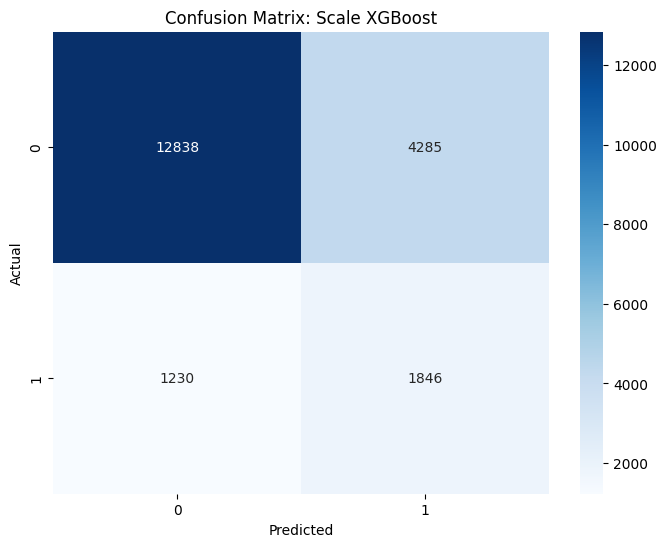

In [68]:
get_confusion_matrix(y_test, y_pred, 'Confusion Matrix: Scale XGBoost')

Finally, We are using GridSearchCV to explore all possible combinations of hyperparameters in XGBoost, aiming to identify the most optimal set of parameters that will maximize the model's performance and accuracy.

In [51]:
%%time
param_grid = {
    'scale_pos_weight': [1, 2, 5, 10], 
    'max_depth': [3, 5, 7],  
    'learning_rate': [0.01, 0.1, 0.2],  
    'n_estimators': [100, 200, 500],  
    'subsample': [0.8, 1.0],  
    'colsample_bytree': [0.8, 1.0]  
}

grid_xgb_model = XGBClassifier(random_state=42)
grid_search = GridSearchCV(
    estimator=grid_xgb_model,
    param_grid=param_grid,
    scoring='f1',  
    cv=5, 
    verbose=2, 
)

grid_search.fit(X_train, y_train)
grid_best_model = grid_search.best_estimator_

Fitting 5 folds for each of 432 candidates, totalling 2160 fits
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, scale_pos_weight=1, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, scale_pos_weight=1, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, scale_pos_weight=1, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, scale_pos_weight=1, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, scale_pos_weight=1, subsample=0.8; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, scale_pos_weight=1, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=0.8, learning_rate=0.01, max_depth=3, n_estimators=100, scale_pos_weight=1, subsample=1.0; tot

In [69]:
y_pred = grid_best_model.predict(X_test)
print("Best Parameters:", grid_best_model.best_params_)
print(classification_report(y_test, y_pred))

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 100, 'scale_pos_weight': 5, 'subsample': 0.8}
              precision    recall  f1-score   support

           0       0.91      0.81      0.86     17123
           1       0.34      0.55      0.42      3076

    accuracy                           0.77     20199
   macro avg       0.62      0.68      0.64     20199
weighted avg       0.82      0.77      0.79     20199



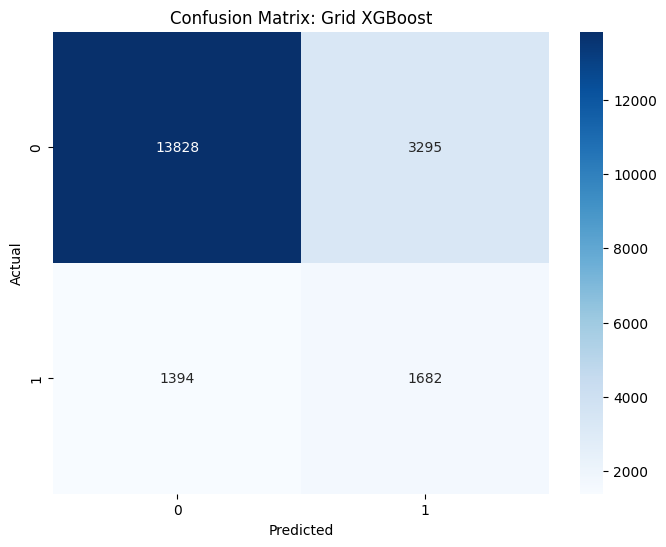

In [73]:
get_confusion_matrix(y_test, y_pred, 'Confusion Matrix: Grid XGBoost')

### Finally, calculate the misclassification cost

In [75]:
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

cost_per_email = 2
total_cost = fp * cost_per_email
print("misclassification cost", total_cost)

6590
